Install & Import Libraries

In [18]:
!pip install kagglehub tensorflow opencv-python matplotlib

In [19]:
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

Download Dataset from Kaggle

In [20]:
# Download latest dataset
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Dataset path:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Dataset path: /kaggle/input/asl-alphabet


Locate Dataset Folder

In [21]:
dataset_path = os.path.join(path, "asl_alphabet_train", "asl_alphabet_train")
print(dataset_path)

# Check available classes
print(os.listdir(dataset_path))

/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train
['N', 'R', 'space', 'B', 'I', 'del', 'F', 'H', 'E', 'U', 'M', 'X', 'K', 'Q', 'Y', 'S', 'G', 'A', 'O', 'T', 'V', 'Z', 'C', 'P', 'L', 'W', 'D', 'nothing', 'J']


Image Preprocessing

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

Load Training Dataset

In [23]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 69600 images belonging to 29 classes.


Load Validation Dataset

In [24]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 17400 images belonging to 29 classes.


Build CNN Model

In [25]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(29,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [26]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,605 (4.89 MB)

 Trainable params: 1,280,605 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [28]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [29]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

Epoch 1/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 715s 328ms/step - accuracy: 0.6093 - loss: 1.2527 - val_accuracy: 0.7252 - val_loss: 0.8974
Epoch 2/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 707s 325ms/step - accuracy: 0.8869 - loss: 0.3316 - val_accuracy: 0.8044 - val_loss: 0.6644
Epoch 3/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 707s 325ms/step - accuracy: 0.9365 - loss: 0.1891 - val_accuracy: 0.8252 - val_loss: 0.5914
Epoch 4/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 716s 329ms/step - accuracy: 0.9548 - loss: 0.1389 - val_accuracy: 0.8253 - val_loss: 0.6362
Epoch 5/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 713s 328ms/step - accuracy: 0.9639 - loss: 0.1107 - val_accuracy: 0.8214 - val_loss: 0.7944


Plot Training Accuracy

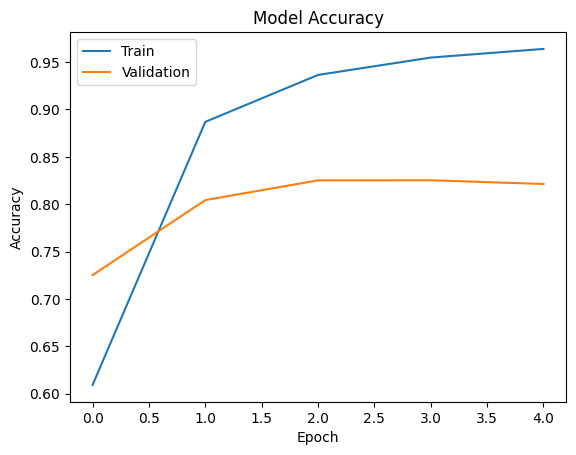

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

Save the Model

In [31]:
model.save("asl_model.h5")

Test Prediction

In [34]:
import cv2
import numpy as np

# The uploaded file is named 'sign.jpg'.
img = cv2.imread("sign.jpg")

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image 'sign.jpg'. Please ensure the file exists and the path is correct.")
else:
    img = cv2.resize(img,(64,64))
    img = img/255.0

    img = np.reshape(img,(1,64,64,3))

    prediction = model.predict(img)

    predicted_class = np.argmax(prediction)

    print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Predicted Class: 16


In [33]:
from google.colab import files

print("Please upload 'test_image.jpg'")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Please upload 'test_image.jpg'


Saving sign.jpg to sign.jpg
User uploaded file "sign.jpg" with length 23360 bytes


Show Input Image with Prediction

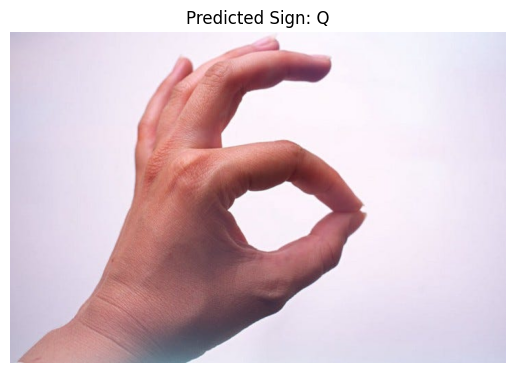

In [36]:
import cv2

# Map predicted class index to label
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
predicted_label = idx_to_class[predicted_class]

# Load the uploaded image (sign.jpg)
img_to_display = cv2.imread("sign.jpg")

# Check if the image was loaded successfully before processing
if img_to_display is None:
    print("Error: Could not load image 'sign.jpg' for display.")
else:
    plt.imshow(cv2.cvtColor(img_to_display, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted Sign: {predicted_label}")
    plt.axis("off")
    plt.show()